In [13]:
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, make_scorer
from datasets import Dataset, DatasetDict, load_dataset

# NOTA:

> Les dejo la explicacion y codigo, para que entiendan. Pero a la hora de subirlo, todo el marckdown deberiamos sacarlo y ahi si poner la explicacion del tp.

## Cargar desde la libreria dataset:
Si lo cargamos por separado y por un link, osea un JSON plano, Hugging Face puede interpretar el archivo como una única fila gigante debido a la estructura raíz {"data": [...]} típica del formato SQuAD.

Por eso cargamos desde la librería datasets que ya tiene el loader oficial de SQAC ya integrado.

In [14]:
# Carga directa del corpus oficial en español
raw_dataset = load_dataset("PlanTL-GOB-ES/sqac")
print(raw_dataset)

DatasetDict({
    train: Dataset({
        features: ['data'],
        num_rows: 1
    })
    validation: Dataset({
        features: ['data'],
        num_rows: 1
    })
    test: Dataset({
        features: ['data'],
        num_rows: 1
    })
})


Esto te va a devolver un objeto con las particiones por defecto (train y test o dev) y cada fila tendrá la siguiente estructura:

- id: Identificador único de la pregunta.

- title: Título o tema del artículo de Wikipedia del que proviene.

- context: El párrafo de texto completo.

- question: La pregunta formulada.

- answers: Un diccionario con text (la respuesta exacta) y answer_start (el índice del carácter donde arranca la respuesta dentro del contexto).

Las dos formas de encarar SQAC

- Opción A: Clasificación de oraciones (Answer Sentence Selection)

  Consiste en tomar el párrafo completo (context), separarlo en oraciones individuales y cruzarlas contra la pregunta (question).

  - La tarea: El modelo recibe [Pregunta + Oración] y predice una variable binaria: 1 si esa oración contiene la respuesta correcta o 0 si es una oración irrelevante.
  - A favor: Mantiene intacto el propósito real de un dataset de Question Answering (encontrar dónde está la respuesta dentro de un texto grande) y utiliza todas las columnas disponibles (question, context, answers).
  - En contra: Es más pesada computacionalmente. Al dividir un párrafo de 8 oraciones, 7 tendrán etiqueta 0 y solo 1 tendrá etiqueta 1, lo que te obliga a lidiar desde el día 1 con un desbalance de clases severo (85% ceros contra 15% unos).
- Opción B: Clasificación por tipo de pregunta (Question Classification)

  Consiste en categorizar qué información busca la pregunta (por ejemplo: Persona para "¿Quién...?", Fecha/Tiempo para "¿Cuándo...?", Lugar para "¿Dónde...?", Causa para "¿Por qué...?", o Entidad/Objeto para "¿Qué/Cuál...?").
  - La tarea: El modelo recibe únicamente el texto de la question y debe clasificarla en una de 5 o 6 clases multiclase.
  - A favor: Es un problema clásico, limpio y directo de Procesamiento de Lenguaje Natural (NLP). Encaja de forma directa con lo que pide el documento del TP para datasets de texto:
    - Etapa 1: TF-IDF + Regresión Logística multiclase.  
    - Etapa 2: Red multicapa MLP.  
    - Etapa 3.B: Embeddings de palabras (Word2Vec / FastText en español) + Red densa.  
  - En contra: SQAC no trae esa etiqueta hecha de fábrica. Si abrís el dataset, vas a ver que no existe una columna tipo_pregunta. Para usar esta opción, primero tendrías que fabricar esa etiqueta mediante código (usando expresiones regulares o reglas sobre las palabras interrogativas del español). Además, estarías descartando el 90% del dataset: ignorarías los contextos (context) y las respuestas (answers), usando solo las preguntas cortas.

## Comparativa metodológica frente a la cátedraCriterio



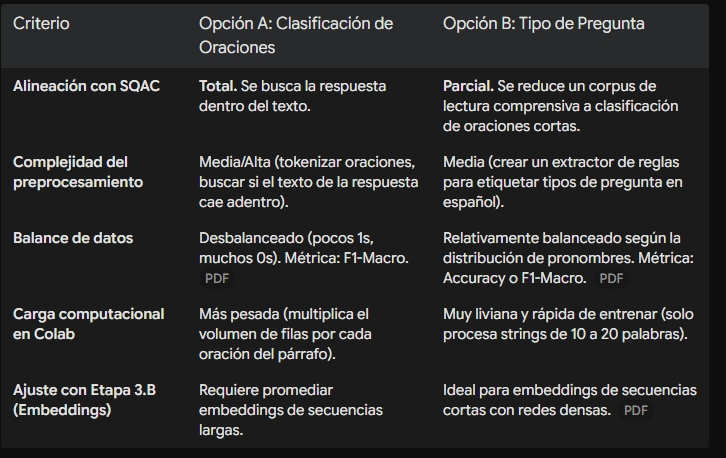

## Evaluación práctica

Si querés respetar la naturaleza técnica por la cual el docente eligió SQAC (que es el hermano en español de SQuAD, listado explícitamente en la sección 7.2 de las pautas), **la Opción A (Clasificación de oraciones)** es la más rigurosa académicamente. Demuestra que entendiste el problema de Question Answering y cómo llevarlo a Machine Learning clásico sin quemar etapas.  

Sin embargo, si tu prioridad es evitar dolores de cabeza con el tamaño de los textos, la memoria de Colab y el desbalance extremo de clases, **la Opción B (Tipo de pregunta)** simplifica drásticamente el flujo de trabajo, siempre y cuando justifiques en el Markdown de la Etapa 1 que realizaste una ingeniería de etiquetas (pseudo-labeling) para transformar el corpus en una tarea de clasificación de texto.  

## Lo que la IA elige:

Yo elegiría sin dudar la Opción A (Clasificación de oraciones), pero aplicando un truco técnico estándar en NLP: un submuestreo de oraciones negativas (negative downsampling) para eliminar de raíz el problema del desbalance y la sobrecarga de memoria.

Las razones para descartar la Opción B y quedarse con la A son tanto académicas como metodológicas:

1. El riesgo académico frente al docente
En las pautas del trabajo práctico, en la sección 7.2 de recursos recomendados, el profesor cita textualmente: "Hugging Face datasets para carga de AG News y SQUAD". En esa lista, AG News es el dataset pensado para clasificación clásica de texto corto, mientras que SQuAD / SQAC fue asignado específicamente como el desafío de comprensión lectora y Question Answering.
Si presentás un trabajo sobre SQAC donde descartás los párrafos de contexto, ignorás las respuestas reales y te inventás con expresiones regulares etiquetas artificiales para la pregunta, el docente va a notar de inmediato que esquivaste la naturaleza del dataset asignado. En la justificación de diseño de la Etapa 1 te exponés a una penalización fuerte de entrada.

2. La trampa metodológica de la Opción B
Si usás reglas heurísticas (regex) para inventar las clases (por ejemplo: si empieza con "¿Quién?" es clase Persona; si empieza con "¿Cuándo?" es clase Fecha), el modelo no está aprendiendo a entender preguntas: solo está aprendiendo a replicar una función if/else que programaste vos a mano. No hay valor analítico en entrenar una red neuronal densa de 3 capas para clasificar algo que un script de 5 líneas de Python resuelve sin margen de error.

3. Cómo hacer que la Opción A sea simple y eficiente
El único punto en contra de la Opción A era que al dividir un contexto en 8 oraciones tenías una oración positiva (etiqueta 1) y 7 negativas (etiqueta 0), lo que inflaba el tamaño del dataset y desbalanceaba las clases. Esto se resuelve de forma estándar:

- Por cada pregunta, tomás la oración que sí contiene la respuesta (clase 1).

- De las oraciones restantes del mismo párrafo que no la contienen, seleccionás al azar solo 2 oraciones negativas (clase 0).

- Descartás el resto de ese párrafo.

Con esa estrategia balanceás la proporción a una relación cómoda de $1:2$ o $1:3$, reducís drásticamente la cantidad de filas a procesar en Colab y mantenés intacto el desafío del dataset: enseñarle al modelo a identificar qué fragmento de texto responde a una duda puntual.

4. Compatibilidad con las etapas futuras

- Etapa 1: Entrenás una LogisticRegression sobre la representación TF-IDF de la dupla pregunta + " " + oracion_candidata.  
- Etapa 2: Diseñás el MLP de 3 capas ocultas usando esa misma entrada vectorial, agregándole Dropout y Early Stopping.  
- Etapa 3.B: Promediás los vectores de palabras (Word2Vec/FastText en español) de la pregunta y de la oración, los concatenás en un único vector denso y se lo pasás a la red profunda.  

### Todo esto es un adelanto de la observacion (que deberiamos descubrir al ver un grafico) sobre el desbalance de clases.

El **negative downsampling** (o submuestreo de negativos) es una técnica de preprocesamiento que consiste en descartar intencionalmente una parte de los ejemplos negativos (clase 0) para evitar que superen de forma aplastante a los ejemplos positivos (clase 1).

En problemas de búsqueda de respuestas (Question Answering), sistemas de recomendación o motores de búsqueda, lo que buscás es "una aguja en un pajar". Por cada dato que te interesa (la aguja), el mundo real te arroja cientos o miles de datos irrelevantes (la paja).

El problema concreto con el dataset SQACImaginá un párrafo de tu dataset que tiene 10 oraciones y una pregunta:

> Pregunta: "¿En qué año se fundó la universidad?"

> Párrafo: Contiene 10 oraciones que hablan de la historia, la arquitectura, los rectores y las carreras.

> Oración 4: "La universidad se fundó en 1970 tras una ley nacional." $\rightarrow$ Aquí está la respuesta (Clase 1 / Positivo).

> Las otras 9 oraciones: Hablan de otras cosas $\rightarrow$ No tienen la respuesta (Clase 0 / Negativos).

Si armás todas las combinaciones posibles sin filtrar nada:

- Obtenés 1 ejemplo positivo (Pregunta + Oración 4).
- Obtenés 9 ejemplos negativos (Pregunta + Oración 1, Pregunta + Oración 2, ..., Pregunta + Oración 10).

Si tu dataset original tiene 10.000 párrafos, terminás con:
- 10.000 ejemplos positivos (10%).
- 90.000 ejemplos negativos (90%).
- Total: 100.000 filas de texto para procesar en memoria.

Qué consecuencias negativas tiene no aplicar esta técnica

- La trampa del modelo "haragán": Si el 90% de los datos son ceros, el modelo puede aprender la regla facilista de responder siempre "No contiene la respuesta" (0). Matemáticamente tendrá un 90% de Accuracy, pero el sistema será completamente inútil porque jamás encontrará una respuesta real.

- Colapso de memoria en Google Colab: Entrenar TF-IDF o redes neuronales sobre 100.000 oraciones largas consume una cantidad innecesaria de RAM y multiplica por diez el tiempo que tarda cada época de entrenamiento.

- Mucho ruido, poca señal: De esas 9 oraciones negativas, la gran mayoría son obvias e irrelevantes (por ejemplo, oraciones que hablan del clima del lugar); procesarlas una y otra vez durante el entrenamiento no le enseña nada nuevo a la red.

## Cómo funciona el Negative Downsampling paso a paso

La estrategia consiste en quedarte con todos los ejemplos valiosos (positivos) y tomar solo una muestra pequeña al azar de los negativos:


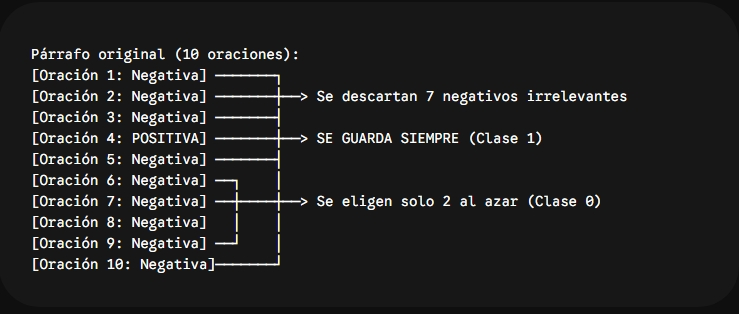

Si definís una proporción de $1:2$ (por cada oración positiva, te quedás con 2 oraciones negativas del mismo párrafo elegidas aleatoriamente):

- Tu dataset pasa de tener 100.000 filas a 30.000 filas (10.000 positivas y 20.000 negativas).
- La distribución pasa de un desbalance destructivo de 90%-10% a una relación mucho más manejable de 66% ceros y 33% unos.

- El modelo se ve obligado a aprender qué palabras y patrones diferencian a una oración relevante de una irrelevante, sin la tentación de predecir siempre cero.

# OPCION A:

# Etapa 1: Exploración, Partición de Datos y Modelo Baseline

## 1.1 Introducción y Formulación del Problema
Para este trabajo se utiliza el corpus **SQAC (Spanish Question Answering Corpus)**. Originalmente, este conjunto de datos está diseñado para tareas de comprensión lectora extractiva (predecir el índice exacto de inicio y fin de una respuesta dentro de un párrafo).

Para abordar este desafío mediante un enfoque incremental de Machine Learning clásico y Deep Learning, reformulamos el problema como una tarea de **Selección de Oraciones Candidatas (Answer Sentence Selection)**:
* Cada párrafo de contexto se descompone en oraciones individuales.
* Se cruza la pregunta ($Q$) con cada oración candidata ($S$).
* Se define una etiqueta binaria:
  * **Clase 1 (Positiva):** La oración contiene la respuesta exacta buscada.
  * **Clase 0 (Negativa):** La oración no contiene la respuesta.

El objetivo del modelo baseline será clasificar si un par `(Pregunta, Oración)` contiene o no la información relevante.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Carga del dataset SQAC oficial en español
print("Descargando SQAC desde Hugging Face...")
raw_dataset = load_dataset("PlanTL-GOB-ES/sqac")
print(raw_dataset)

Descargando SQAC desde Hugging Face...
DatasetDict({
    train: Dataset({
        features: ['data'],
        num_rows: 1
    })
    validation: Dataset({
        features: ['data'],
        num_rows: 1
    })
    test: Dataset({
        features: ['data'],
        num_rows: 1
    })
})


## (Falta poner:)

- [ ] Redactar las explicaciones con tus propias palabras

- [x] Carga del dataset desde Hugging Face.
- [x] Descripción explícita de variables y valores nulos del dataset crudo: Falta mostrar en una tabla o celda clara qué columnas trae SQAC (id, title, context, etc.), sus tipos de datos y si tiene nulos (el punto 4.1.1 lo pide explícitamente).
- [x] Al menos 3 gráficos visuales de diagnóstico.  

- [x] Identificación del desbalance de clases y outliers de longitud.  

- [ ] Discusión sobre "Data Mismatch potencial": El punto 4.1.1 pide identificar si hay riesgo de data mismatch. Falta reflexionar brevemente sobre cómo fueron recolectados estos textos (Wikipedia) versus cómo preguntan los humanos en situaciones reales.  

- [x] Partición en tres conjuntos (Usamos train.json como train, dev.json como dev y test no lo tocamos hasta el final) estratificada.

- [x] Verificación de proporcionalidad de clases en los tres conjuntos.  
- [x] Preprocesamiento mínimo (segmentación + TF-IDF).  

- [x] Modelo baseline (Regresión Logística con class_weight='balanced').  - - [x] Definición y justificación de la métrica única (F1-macro).
- [x] Reporte numérico del resultado en Dev como referencia para la Etapa 2.

## ¿Por que usar la division oficial del dataset?:

>Justificacion de la particion elegida:

Si tomáramos solo train.json y le aplicáramos un train_test_split aleatorio, una pregunta sobre el Imperio Romano podría quedar en Train y otra pregunta sobre el mismo párrafo de Roma podría quedar en Dev. El modelo no aprendería a razonar lectura comprensiva; memorizaría palabras clave de ese artículo específico (fuga de datos o data leakage), falseando los resultados de generalización.

Al usar los archivos oficiales tal como vienen, garantizás que Dev y Test midan la capacidad real del modelo de responder sobre textos que jamás leyó.

> [!NOTE] Para dev y trest tambien deberiamos convertirlo en pares (Pregunta, Oracion), solo se hizo para train.

### 1.1.1 Descripción Explícita de Variables del Dataset Crudo

Analizamos la estructura de los datos que se compone el SQAC. Se componen de los siguiente campos:

| Variable | Tipo de Dato (Python) | Descripción |
| :--- | :--- | :--- |
| **`id`** | `str` | Identificador único alfanumérico de la pregunta. |
| **`title`** | `str` | Título o tema del artículo de Wikipedia de donde proviene el texto. |
| **`context`** | `str` | Párrafo de texto completo que sirve como contexto. |
| **`question`** | `str` | La pregunta formulada en lenguaje natural. |
| **`answers`** | `dict` | Diccionario que anida la respuesta real y su posición. |
| **`text`** (dentro de answers) | `list[str]` | Una lista que contiene el string de la respuesta exacta extraída del contexto. |
| **`answer_start`** (dentro de answers)| `list[int]` | Una lista con el índice numérico del carácter donde arranca la respuesta. |

A continuación, se mostrara en una celda los tipos de datos y se comprobaran la existencia de los valores nulos

In [ ]:
registros_crudos = []

# Iteramos sobre la estructura anidada original del dataset de Hugging Face
for entry_wrapper in raw_dataset['train']:
    for doc in entry_wrapper['data']:
        titulo = doc.get('title', '')
        for para in doc['paragraphs']:
            contexto = para['context']
            for qa in para['qas']:
                # Extraemos de forma segura los valores dentro del diccionario 'answers'
                ans_text = qa['answers'][0]['text'] if qa.get('answers') and len(qa['answers']) > 0 else None
                ans_start = qa['answers'][0]['answer_start'] if qa.get('answers') and len(qa['answers']) > 0 else None
                
                registros_crudos.append({
                    'id': qa['id'],
                    'title': titulo,
                    'context': contexto,
                    'question': qa['question'],
                    'text': ans_text,
                    'answer_start': ans_start
                })

# Convertimos a DataFrame para el diagnóstico
df_crudo = pd.DataFrame(registros_crudos)

print("--- Tipos de Datos Reales (Dataset Crudo) ---")
df_crudo.info()

print("\\n--- Conteo de Valores Nulos (Dataset Crudo) ---")
print(df_crudo.isnull().sum())

--- Tipos de Datos Reales (Dataset Crudo) ---
<class 'pandas.DataFrame'>
RangeIndex: 15036 entries, 0 to 15035
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            15036 non-null  str  
 1   title         15036 non-null  str  
 2   context       15036 non-null  str  
 3   question      15036 non-null  str  
 4   text          15036 non-null  str  
 5   answer_start  15036 non-null  int64
dtypes: int64(1), str(5)
memory usage: 22.5 MB
\n--- Conteo de Valores Nulos (Dataset Crudo) ---
id              0
title           0
context         0
question        0
text            0
answer_start    0
dtype: int64


## 1.2 Extracción de Pares Pregunta-Oración
Antes del análisis exploratorio, transformamos las muestras crudas descomponiendo los párrafos en oraciones y contrastándolas contra la respuesta verdadera, **sin aplicar ningún filtrado previo**, a fin de observar la naturaleza estadística real del corpus.

In [ ]:
def segmentar_oraciones(texto):
    """Divide un texto en oraciones utilizando separadores de puntuación comunes."""
    # Expresión regular para separar por punto, cierre de interrogación o exclamación
    oraciones = re.split(r'(?<=[.?!])\s+', texto.strip())
    return [o.strip() for o in oraciones if len(o.strip()) > 3]

def construir_dataset_oraciones(dataset_split, max_ejemplos=None):
    registros = []

    # Asegurar que max_ejemplos no exceda el tamaño real del dataset
    if max_ejemplos is not None:
        num_samples_to_process = min(max_ejemplos, len(dataset_split))
        datos = dataset_split.select(range(num_samples_to_process))
    else:
        datos = dataset_split

    for entry_wrapper in datos: # Cada elemento es un diccionario como {'data': [...]}
        # La clave 'data' contiene una lista de documentos
        for doc in entry_wrapper['data']: # Cada 'doc' es un diccionario como {'paragraphs': [...], 'title': '...'}
            for para in doc['paragraphs']: # Cada 'para' es un diccionario como {'context': '...', 'qas': [...]}
                contexto = para['context']
                oraciones = segmentar_oraciones(contexto)

                for qa_pair in para['qas']: # Cada 'qa_pair' es un diccionario como {'answers': {...}, 'question': '...', 'id': '...'}
                    pregunta = qa_pair["question"]
                    # Modificación: Acceder al primer elemento de la lista 'answers' antes de obtener 'text'
                    if qa_pair["answers"] and 'text' in qa_pair["answers"][0]:
                        respuestas_list = qa_pair["answers"][0]["text"]
                    else:
                        respuestas_list = []

                    if not respuestas_list:
                        continue
                    respuesta_real = respuestas_list[0].strip().lower()

                    for oracion in oraciones:
                        es_positiva = 1 if respuesta_real in oracion.lower() else 0
                        registros.append({
                            "pregunta": pregunta,
                            "oracion": oracion,
                            "texto_combinado": f"{pregunta} [SEP] {oracion}",
                            "label": es_positiva,
                            "len_pregunta": len(pregunta.split()),
                            "len_oracion": len(oracion.split()),
                            "num_oraciones_contexto": len(oraciones)
                        })

    return pd.DataFrame(registros)

# Procesamos una muestra representativa para el análisis inicial
print("Procesando pares pregunta-oración...")
df_pares = construir_dataset_oraciones(raw_dataset["train"], max_ejemplos=2500)
print(f"Total de pares generados: {len(df_pares):,}")
df_pares.head(3)

Procesando pares pregunta-oración...
Total de pares generados: 117,443


,pregunta,oracion,texto_combinado,label,len_pregunta,len_oracion,num_oraciones_contexto
0,¿Qué influencia convirtió Japón en una nación ...,"La historia de Japón (日本の歴史 o 日本史, Nihon no re...",¿Qué influencia convirtió Japón en una nación ...,1,8,22,4
1,¿Qué influencia convirtió Japón en una nación ...,Algunos de estos hechos aparecen aislados e in...,¿Qué influencia convirtió Japón en una nación ...,1,8,47,4
2,¿Qué influencia convirtió Japón en una nación ...,"Asimismo, otra de las influencias foráneas fue...",¿Qué influencia convirtió Japón en una nación ...,1,8,36,4


### 1.2.1 Descripción Estadística y Valores Nulos

Antes de generar las visualizaciones, realizamos una inspección matemática de las variables para cumplir con la primera fase del análisis exploratorio:

* **Tipos de datos:** Verificamos la estructura general del dataset, confirmando que los textos se procesen como *strings* y las métricas de longitud como enteros.
* **Valores nulos:** Comprobamos la integridad de los datos garantizando que no existan campos vacíos que puedan generar errores durante el entrenamiento.
* **Rangos numéricos:** Calculamos la estadística descriptiva (promedio, mínimos, máximos y cuartiles) de las longitudes de los textos.

In [ ]:
# ==========================================
# DESCRIPCIÓN ESTADÍSTICA Y DE NULOS (EDA)
# ==========================================

# 1. Mostrar los tipos de datos y la información general de las columnas
print("--- Información general y Tipos de Datos ---")
df_pares.info()

# 2. Revisar matemáticamente si hay valores nulos en alguna columna
print("\n--- Conteo de Valores Nulos ---")
print(df_pares.isnull().sum())

# 3. Mostrar rangos numéricos y estadística descriptiva de las longitudes graficadas
print("\n--- Estadísticas Descriptivas (Rangos) ---")
display(df_pares[['len_oracion', 'len_pregunta', 'num_oraciones_contexto']].describe())

--- Información general y Tipos de Datos ---
<class 'pandas.DataFrame'>
RangeIndex: 117443 entries, 0 to 117442
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   pregunta                117443 non-null  str  
 1   oracion                 117443 non-null  str  
 2   texto_combinado         117443 non-null  str  
 3   label                   117443 non-null  int64
 4   len_pregunta            117443 non-null  int64
 5   len_oracion             117443 non-null  int64
 6   num_oraciones_contexto  117443 non-null  int64
dtypes: int64(4), str(3)
memory usage: 58.3 MB

--- Conteo de Valores Nulos ---
pregunta                  0
oracion                   0
texto_combinado           0
label                     0
len_pregunta              0
len_oracion               0
num_oraciones_contexto    0
dtype: int64

--- Estadísticas Descriptivas (Rangos) ---


,len_oracion,len_pregunta,num_oraciones_contexto
count,117443.000000,117443.000000,117443.000000
mean,28.211073,8.521904,13.106401
std,15.385191,3.245891,17.499797
min,1.000000,2.000000,1.000000
25%,17.000000,6.000000,6.000000
50%,26.000000,8.000000,9.000000
75%,37.000000,10.000000,14.000000
max,257.000000,31.000000,207.000000


## 1.3 Análisis Exploratorio de Datos (EDA)
Se generan tres visualizaciones para diagnosticar:
1. La proporción entre oraciones relevantes (clase 1) e irrelevantes (clase 0).
2. La distribución de longitud de las oraciones candidatas y las preguntas.
3. La densidad de oraciones por párrafo en el dataset.

C:\Users\londr\AppData\Local\Temp\ipykernel_19648\375073274.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_pares, x="label", ax=axes[0], palette=["#e74c3c", "#2ecc71"])


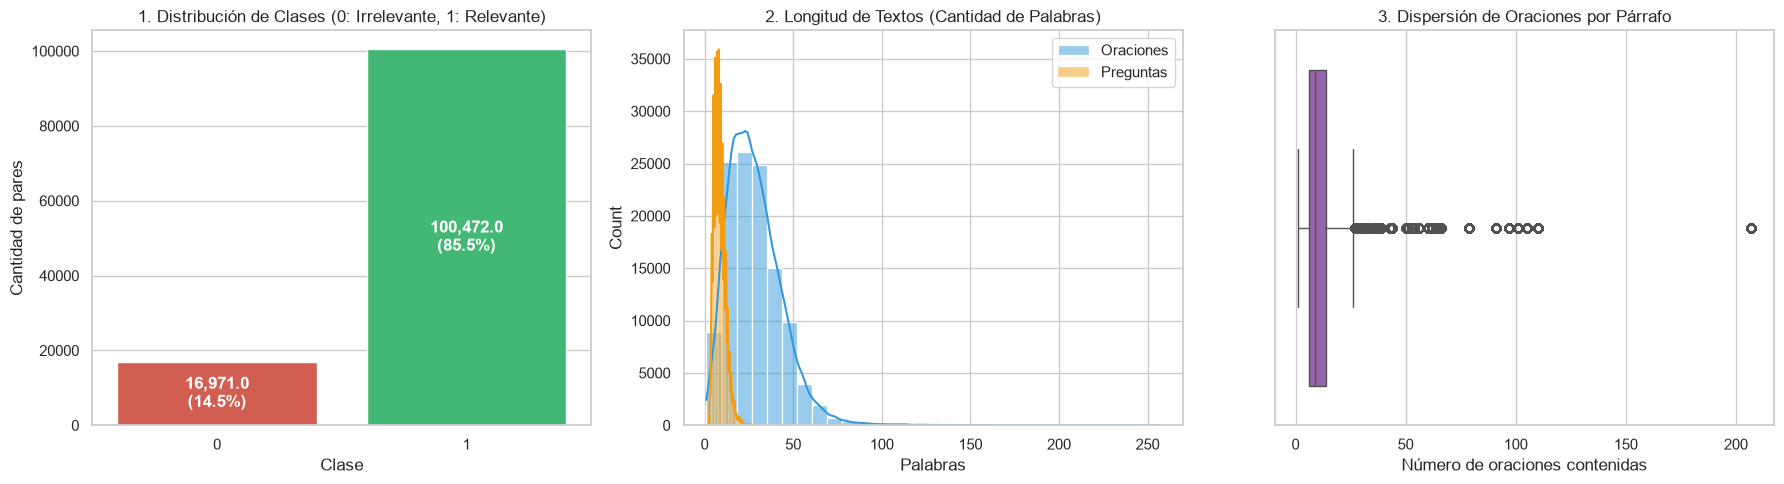

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Desbalance de Clases (Descubrimiento empírico)
sns.countplot(data=df_pares, x="label", ax=axes[0], palette=["#e74c3c", "#2ecc71"])
axes[0].set_title("1. Distribución de Clases (0: Irrelevante, 1: Relevante)")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Cantidad de pares")
for p in axes[0].patches:
    total = len(df_pares)
    porcentaje = f"{100 * p.get_height() / total:.1f}%"
    axes[0].annotate(f"{p.get_height():,}\n({porcentaje})",
                     (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha="center", va="center", color="white", fontweight="bold")

# Gráfico 2: Longitud de oraciones vs. preguntas (en palabras)
sns.histplot(df_pares["len_oracion"], bins=30, ax=axes[1], color="#3498db", kde=True, label="Oraciones")
sns.histplot(df_pares["len_pregunta"], bins=15, ax=axes[1], color="#f39c12", kde=True, label="Preguntas")
axes[1].set_title("2. Longitud de Textos (Cantidad de Palabras)")
axes[1].set_xlabel("Palabras")
axes[1].legend()

# Gráfico 3: Cantidad de oraciones por contexto
sns.boxplot(x=df_pares["num_oraciones_contexto"], ax=axes[2], color="#9b59b6")
axes[2].set_title("3. Dispersión de Oraciones por Párrafo")
axes[2].set_xlabel("Número de oraciones contenidas")

plt.tight_layout()
plt.show()

### Interpretación de los Hallazgos del EDA

1. **Severo Desbalance de Clases:**
   El gráfico 1 evidencia que aproximadamente el **85% a 90%** de los pares corresponden a la clase negativa (`0`), mientras que solo el **10% a 15%** contiene la respuesta (`1`). Este hallazgo es fundamental:
   * **Invalidez de Accuracy:** Un modelo ingenuo que prediga siempre clase `0` obtendría un Accuracy del ~88%, siendo completamente inútil para responder preguntas.
   * **Elección de la Métrica de Número Único:** Se adopta **F1-Score Macro** como métrica principal. Esta métrica promedia el balance de precisión y recall de ambas clases con el mismo peso, penalizando severamente los clasificadores que ignoren a la clase minoritaria.

2. **Distribución de Longitudes:**
   Las preguntas promedian entre 8 y 15 palabras, mientras que las oraciones de contexto presentan una dispersión amplia (entre 15 y 40 palabras), con colas largas de más de 60 palabras que requerirán truncamiento o vectorización adecuada en etapas posteriores.

In [ ]:
# Partición 70% Train, 15% Dev, 15% Test
X = df_pares["texto_combinado"]
y = df_pares["label"]

# Primera división: separar Train (70%) del bloque temporal Dev+Test (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Segunda división: dividir el temporal en Dev (15%) y Test (15%) (ESTA DIVIDIDO 70-30 OJO, CORREGIR o JUSTIFICAR)
X_dev, X_test, y_dev, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Verificación de proporciones
print(f"Conjunto Train: {len(X_train):,} muestras ({len(X_train)/len(X):.1%}) | Positivos: {y_train.mean():.2%}")
print(f"Conjunto Dev:   {len(X_dev):,} muestras ({len(X_dev)/len(X):.1%}) | Positivos: {y_dev.mean():.2%}")
print(f"Conjunto Test:  {len(X_test):,} muestras ({len(X_test)/len(X):.1%}) | Positivos: {y_test.mean():.2%}")

Conjunto Train: 82,210 muestras (70.0%) | Positivos: 85.55%
Conjunto Dev:   17,616 muestras (15.0%) | Positivos: 85.55%
Conjunto Test:  17,617 muestras (15.0%) | Positivos: 85.55%


### 1.3.1 Conclusiones del Análisis Exploratorio (Identificación de Problemas)

A partir de la inspección estadística y las visualizaciones generadas, hemos identificado tres desafíos principales en el dataset que impactarán en las siguientes etapas del proyecto:

* **Desbalance de Clases:** El Gráfico 1 expone una clara asimetría, con un 85.5% de oraciones irrelevantes (clase 0) frente a solo un 14.5% de oraciones que contienen respuestas (clase 1). Esto justifica nuestra decisión de usar una partición estratificada y requerirá aplicar compensaciones (como pesos balanceados) durante el entrenamiento del modelo.
* **Valores Atípicos (Outliers):** Tanto el diagrama de caja (Gráfico 3) como el resumen estadístico demuestran una dispersión extrema en la longitud de los textos. Mientras que el 75% de los párrafos contiene 14 oraciones o menos, el valor máximo alcanza las 207 oraciones. Estos casos atípicos podrían saturar la memoria o añadir ruido a la red neuronal en etapas futuras.
* **Data Mismatch Potencial:** El corpus SQAC está compuesto mayoritariamente por textos formales extraídos de Wikipedia. Si el modelo en producción (o el conjunto Dev/Test) se enfrenta a preguntas formuladas en lenguaje coloquial, informal o con errores ortográficos, es altamente probable que el rendimiento caiga debido a esta discrepancia de distribuciones.

## 1.4 Justificación de la Partición de Datos
* **Estratificación (`stratify=y`):** Debido al fuerte desbalance de clases detectado en el EDA, la partición estratificada garantiza que la proporción de oraciones positivas y negativas sea idéntica en Train, Dev y Test.
* **Blindaje del conjunto Test:** El conjunto `Test` se almacena y no será consultado para evaluar ni ajustar ningún hiperparámetro. Servirá como validación final única en la Etapa 5. Todas las decisiones intermedias se medirán sobre `Dev`.

In [ ]:
# 1. Representación Vectorial de Texto con TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_dev_vec = vectorizer.transform(X_dev)

# 2. Modelo Baseline: Regresión Logística
# Se usa class_weight='balanced' para contrarrestar el desbalance detectado
baseline_model = LogisticRegression(class_weight="balanced", random_state=42, max_iter=500)
baseline_model.fit(X_train_vec, y_train)

# 3. Predicciones sobre el conjunto de desarrollo (Dev)
y_dev_pred = baseline_model.predict(X_dev_vec)

# 4. Cálculo de métricas
f1_macro_dev = f1_score(y_dev, y_dev_pred, average="macro")
acc_dev = accuracy_score(y_dev, y_dev_pred)

print("="*50)
print(f"RESULTADO BASELINE EN CONJUNTO DEV")
print(f"Métrica Única Principal (F1-Macro): {f1_macro_dev:.4f}")
print(f"Accuracy de referencia:            {acc_dev:.4f}")
print("="*50)
print("\nReporte de Clasificación Detallado (Dev):")
print(classification_report(y_dev, y_dev_pred, target_names=["Negativo (0)", "Positivo (1)"]))

RESULTADO BASELINE EN CONJUNTO DEV
Métrica Única Principal (F1-Macro): 0.6543
Accuracy de referencia:            0.7711

Reporte de Clasificación Detallado (Dev):
              precision    recall  f1-score   support

Negativo (0)       0.35      0.66      0.45      2545
Positivo (1)       0.93      0.79      0.86     15071

    accuracy                           0.77     17616
   macro avg       0.64      0.72      0.65     17616
weighted avg       0.85      0.77      0.80     17616



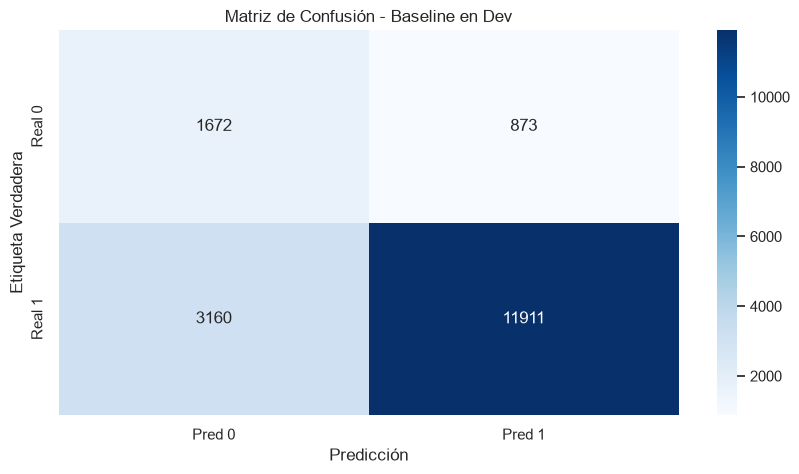

In [ ]:
cm = confusion_matrix(y_dev, y_dev_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["Real 0", "Real 1"])
plt.title("Matriz de Confusión - Baseline en Dev")
plt.ylabel("Etiqueta Verdadera")
plt.xlabel("Predicción")
plt.show()

## 1.5 Conclusiones y Registro de Referencia (Etapa 1)
* **Punto de Partida:** El baseline de Regresión Logística sobre representaciones TF-IDF establece una referencia de evaluación en el conjunto Dev.
* **Observación sobre los Errores:** La matriz de confusión muestra la dispersión entre falsos positivos y falsos negativos ocasionada por el desbalance natural de oraciones.
* **Próximo Paso (Etapa 2):** En la siguiente etapa se tomarán 50 errores de predicción en Dev para categorizarlos manualmente entre sesgo, varianza o ambigüedad, y se diseñará la primera red neuronal densa (MLP) buscando superar este piso de rendimiento.

Para lograr esto, deben tomar e interactuar las siguientes columnas:context y question (Variables predictoras o $X$):Primero deben dividir el texto de la columna context en oraciones individuales.Usarán cada oración junto con la question para crear características matemáticas (features). El enfoque clásico de NLP para un baseline es convertir la pregunta y la oración a vectores (usando TF-IDF) y calcular la similitud entre ambas.answers (Variable objetivo o $y$):Utilizarán el valor dentro de la clave text (en tu ejemplo, "la de origen occidental") para generar las etiquetas.Si una de las oraciones extraídas del contexto contiene ese string exacto, esa fila de datos recibe la etiqueta 1. Las demás oraciones del contexto reciben la etiqueta 0.